In [1]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(".."))
import config

METRICS_DIR  = os.path.join("..", config.OUTPUTS_METRICS)
PLOTS_DIR    = os.path.join("..", config.OUTPUTS_PLOTS)
FEATURES_DIR = os.path.join("..", config.FEATURES_DATA_DIR)
FORECAST_DIR = os.path.join("..", config.OUTPUTS_FORECASTS)
MODELS_DIR   = os.path.join("..", config.MODELS_DIR)
CITIES       = list(config.CITIES.keys())
DAYTIME_THR  = config.DAYTIME_THR

os.makedirs(FORECAST_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,    exist_ok=True)

plt.rcParams.update({
    "figure.dpi"     : 120,
    "axes.titlesize" : 11,
    "axes.labelsize" : 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

print("✅ Imports ready")

✅ Imports ready


In [2]:
# Load all result CSVs
base_df = pd.read_csv(
    os.path.join(METRICS_DIR, "baseline_results.csv")
)
lstm_df = pd.read_csv(
    os.path.join(METRICS_DIR, "lstm_results.csv")
)
snn_df  = pd.read_csv(
    os.path.join(METRICS_DIR, "snn_results.csv")
)

# Standardise column names
for df in [base_df, lstm_df, snn_df]:
    df.columns = df.columns.str.strip()

# Add horizon=1 to baseline if missing
if "horizon" not in base_df.columns:
    base_df["horizon"] = 1

# Combine all into one master dataframe
master_df = pd.concat([base_df, lstm_df, snn_df],
                       ignore_index=True)

print("📋 Results loaded:")
print(f"   Baseline models : "
      f"{base_df['model'].nunique()} models × "
      f"{base_df['city'].nunique()} cities")
print(f"   LSTM models     : "
      f"{lstm_df['model'].nunique()} configs × "
      f"{lstm_df['city'].nunique()} cities")
print(f"   SNN models      : "
      f"{snn_df['model'].nunique()} configs × "
      f"{snn_df['city'].nunique()} cities")
print(f"\n   Total records   : {len(master_df)}")
print(f"   Columns         : {list(master_df.columns)}")

📋 Results loaded:
   Baseline models : 6 models × 10 cities
   LSTM models     : 1 configs × 10 cities
   SNN models      : 1 configs × 10 cities

   Total records   : 80
   Columns         : ['model', 'RMSE', 'MAE', 'MAPE', 'R2', 'city', 'horizon', 'Skill']


In [3]:
h1 = master_df[master_df["horizon"] == 1].copy()

# Pivot RMSE by model × city
rmse_pivot = h1.pivot_table(
    index="model", columns="city", values="RMSE", aggfunc="mean"
)
rmse_pivot["MEAN"] = rmse_pivot.mean(axis=1)
rmse_pivot         = rmse_pivot.sort_values("MEAN")

# Pivot R² by model × city
r2_pivot = h1.pivot_table(
    index="model", columns="city", values="R2", aggfunc="mean"
)
r2_pivot["MEAN"] = r2_pivot.mean(axis=1)
r2_pivot         = r2_pivot.sort_values("MEAN", ascending=False)

# Pivot Skill Score
skill_pivot = h1.pivot_table(
    index="model", columns="city", values="Skill", aggfunc="mean"
)
skill_pivot["MEAN"] = skill_pivot.mean(axis=1)
skill_pivot         = skill_pivot.sort_values("MEAN", ascending=False)

print("=" * 70)
print("  RMSE COMPARISON (W/m²) — H=1 — ALL MODELS × ALL CITIES")
print("=" * 70)
print(rmse_pivot.round(2).to_string())

print("\n\n" + "=" * 70)
print("  R² COMPARISON — H=1")
print("=" * 70)
print(r2_pivot.round(4).to_string())

print("\n\n" + "=" * 70)
print("  SKILL SCORE (%) — H=1 — Higher = Better vs Persistence")
print("=" * 70)
print(skill_pivot.round(2).to_string())

# Save pivot tables
rmse_pivot.to_csv(
    os.path.join(METRICS_DIR, "rmse_comparison.csv")
)
r2_pivot.to_csv(
    os.path.join(METRICS_DIR, "r2_comparison.csv")
)

  RMSE COMPARISON (W/m²) — H=1 — ALL MODELS × ALL CITIES
city               cairo  dubai  istanbul  london  los_angeles  nairobi  new_delhi  riyadh  sydney  tokyo   MEAN
model                                                                                                           
NeuroSpike_h1      28.02  26.99     27.74   28.27        27.44    34.35      35.31   23.90   34.04  30.60  29.67
BiLSTM_h1          40.57  34.70     37.68   41.41        49.66    52.12      54.44   38.09   60.49  46.02  45.52
RandomForest       32.90  25.91     46.89   53.07        38.89    57.68      55.23   25.71   64.30  59.01  45.96
XGBoost            31.77  27.16     48.91   52.88        39.43    60.53      58.29   25.74   68.09  60.01  47.28
Ridge              36.35  26.37     59.17   60.16        53.07    67.70      60.87   27.47   81.25  70.75  54.32
LinearRegression   36.46  26.74     59.21   59.98        52.99    67.74      60.89   27.52   81.58  70.91  54.40
Climatology        45.62  36.56     70.

In [4]:
print("=" * 65)
print("  BEST MODEL PER CITY (by RMSE, h=1)")
print("=" * 65)
print(f"\n  {'City':<14} {'Best Model':<22} "
      f"{'RMSE':>8} {'R²':>8} {'Skill':>8}")
print(f"  {'─'*14} {'─'*22} {'─'*8} {'─'*8} {'─'*8}")

city_winners = []
for city in CITIES:
    city_h1 = h1[h1["city"] == city].sort_values("RMSE")
    if len(city_h1) == 0:
        continue
    best = city_h1.iloc[0]
    city_winners.append({
        "city"       : city,
        "best_model" : best["model"],
        "RMSE"       : best["RMSE"],
        "R2"         : best["R2"],
        "Skill"      : best.get("Skill", np.nan),
    })
    print(f"  {city:<14} {best['model']:<22} "
          f"{best['RMSE']:>8.3f} "
          f"{best['R2']:>8.4f} "
          f"{best.get('Skill', np.nan):>7.1f}%")

winners_df = pd.DataFrame(city_winners)
print(f"\n  Model win counts:")
print(winners_df["best_model"].value_counts().to_string())

winners_df.to_csv(
    os.path.join(METRICS_DIR, "city_winners.csv"), index=False
)

  BEST MODEL PER CITY (by RMSE, h=1)

  City           Best Model                 RMSE       R²    Skill
  ────────────── ────────────────────── ──────── ──────── ────────
  riyadh         NeuroSpike_h1            23.905   0.9950    78.4%
  cairo          NeuroSpike_h1            28.019   0.9924    72.8%
  istanbul       NeuroSpike_h1            27.742   0.9888    65.3%
  new_delhi      NeuroSpike_h1            35.313   0.9806    59.2%
  dubai          RandomForest             25.914   0.9923     nan%
  london         NeuroSpike_h1            28.267   0.9797    51.3%
  sydney         NeuroSpike_h1            34.041   0.9853    63.3%
  tokyo          NeuroSpike_h1            30.602   0.9841    62.2%
  los_angeles    NeuroSpike_h1            27.437   0.9921    71.8%
  nairobi        NeuroSpike_h1            34.351   0.9873    67.2%

  Model win counts:
best_model
NeuroSpike_h1    9
RandomForest     1


In [5]:
print("=" * 65)
print("  MULTI-HORIZON COMPARISON — BiLSTM vs NeuroSpike")
print("=" * 65)

for horizon in [1, 6, 24]:
    print(f"\n  Horizon = {horizon}h ahead")
    print(f"  {'City':<14} {'BiLSTM RMSE':>13} "
          f"{'SNN RMSE':>11} {'Winner':>8}")
    print(f"  {'─'*14} {'─'*13} {'─'*11} {'─'*8}")

    for city in CITIES:
        lstm_row = lstm_df[
            (lstm_df["city"] == city) &
            (lstm_df["horizon"] == horizon)
        ]
        snn_row  = snn_df[
            (snn_df["city"] == city) &
            (snn_df["horizon"] == horizon)
        ]
        if len(lstm_row) == 0 or len(snn_row) == 0:
            continue

        lr = lstm_row["RMSE"].values[0]
        sr = snn_row["RMSE"].values[0]
        w  = "SNN 🏆" if sr < lr else "LSTM 🏆"
        print(f"  {city:<14} {lr:>13.3f} {sr:>11.3f} {w:>8}")

  MULTI-HORIZON COMPARISON — BiLSTM vs NeuroSpike

  Horizon = 1h ahead
  City             BiLSTM RMSE    SNN RMSE   Winner
  ────────────── ───────────── ─────────── ────────
  riyadh                38.093      23.905    SNN 🏆
  cairo                 40.574      28.019    SNN 🏆
  istanbul              37.680      27.742    SNN 🏆
  new_delhi             54.440      35.313    SNN 🏆
  dubai                 34.705      26.992    SNN 🏆
  london                41.407      28.267    SNN 🏆
  sydney                60.494      34.041    SNN 🏆
  tokyo                 46.015      30.602    SNN 🏆
  los_angeles           49.663      27.437    SNN 🏆
  nairobi               52.124      34.351    SNN 🏆

  Horizon = 6h ahead
  City             BiLSTM RMSE    SNN RMSE   Winner
  ────────────── ───────────── ─────────── ────────

  Horizon = 24h ahead
  City             BiLSTM RMSE    SNN RMSE   Winner
  ────────────── ───────────── ─────────── ────────


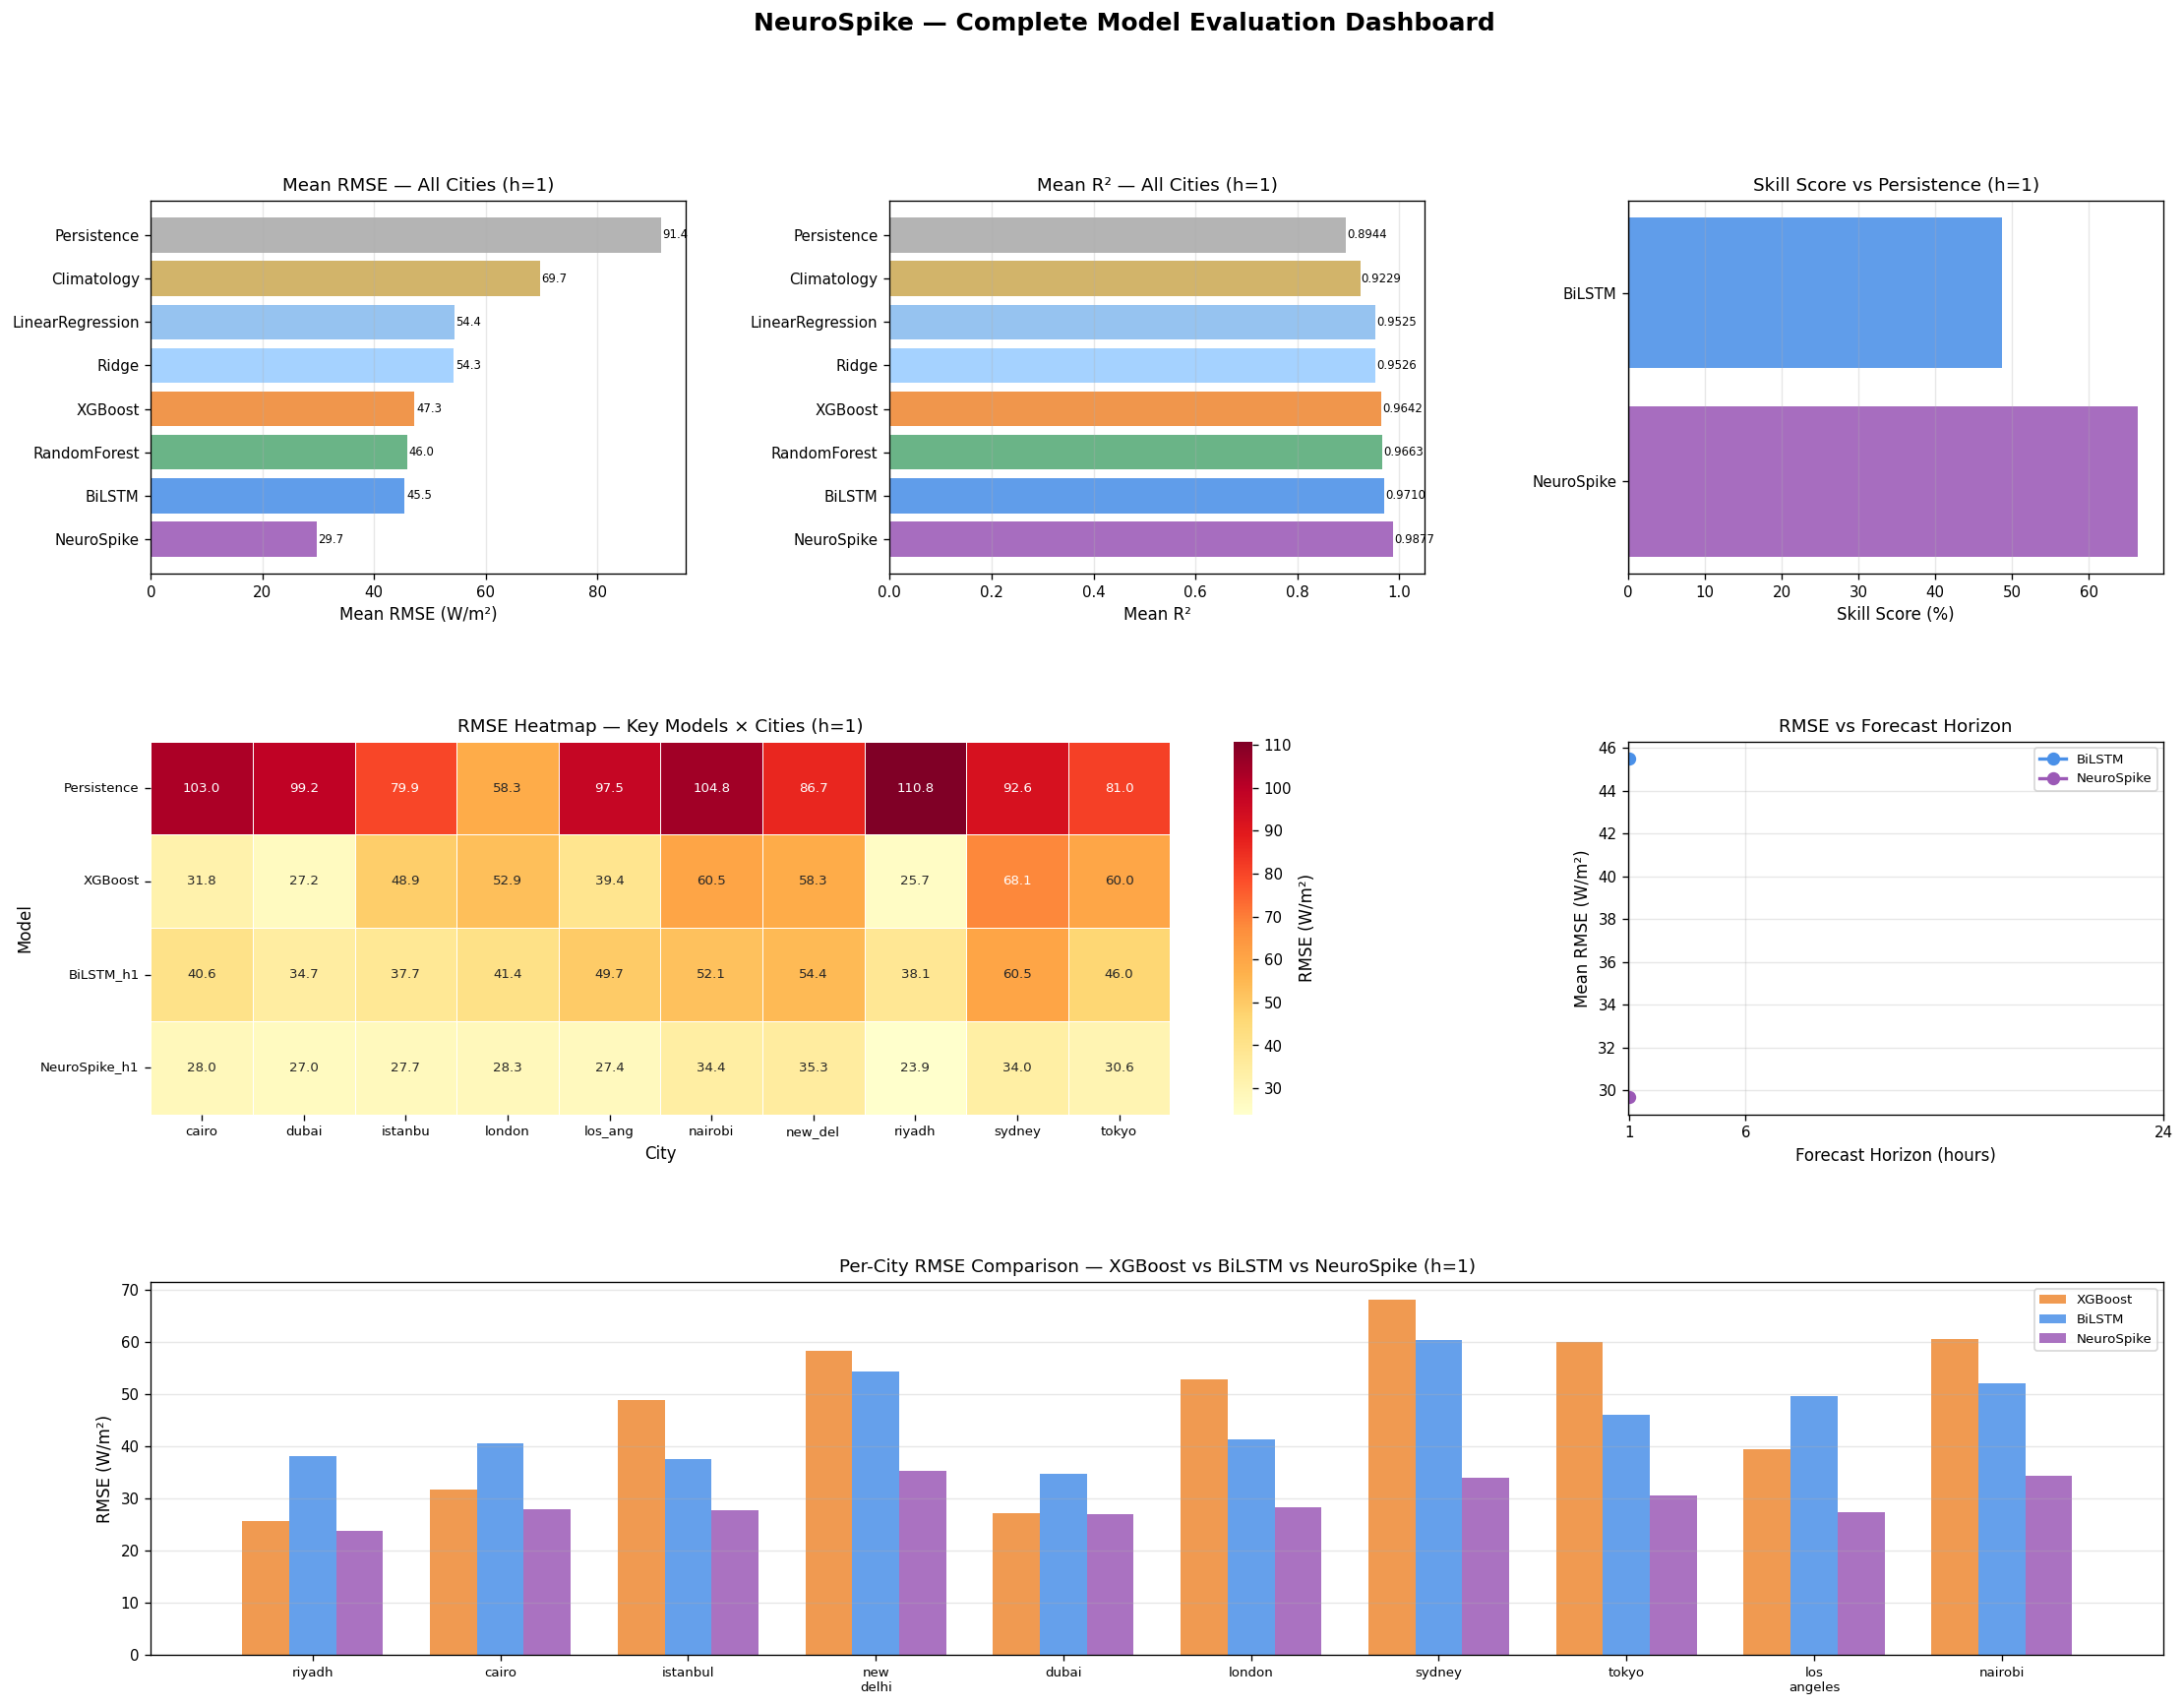

💾 Saved → ..\outputs/plots\09_evaluation_dashboard.png


In [6]:
fig = plt.figure(figsize=(22, 16))
fig.suptitle(
    "NeuroSpike — Complete Model Evaluation Dashboard",
    fontsize=15, fontweight="bold"
)
gs = gridspec.GridSpec(3, 3, figure=fig,
                        hspace=0.45, wspace=0.38)

MODEL_COLORS = {
    "Persistence"    : "#AAAAAA",
    "Climatology"    : "#CCAA55",
    "LinearRegression": "#88BBEE",
    "Ridge"          : "#99CCFF",
    "RandomForest"   : "#55AA77",
    "XGBoost"        : "#EE8833",
    "BiLSTM_h1"      : "#4A90E8",
    "NeuroSpike_h1"  : "#9B59B6",
}

# ── 1: Mean RMSE bar chart ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
mean_rmse = (h1.groupby("model")["RMSE"]
               .mean()
               .sort_values())
colors    = [MODEL_COLORS.get(m, "#999999")
             for m in mean_rmse.index]
bars = ax1.barh(
    [m.replace("_h1","") for m in mean_rmse.index],
    mean_rmse.values,
    color=colors, alpha=0.88
)
ax1.set_xlabel("Mean RMSE (W/m²)")
ax1.set_title("Mean RMSE — All Cities (h=1)")
ax1.grid(True, alpha=0.3, axis="x")
for bar, val in zip(bars, mean_rmse.values):
    ax1.text(bar.get_width() + 0.3,
             bar.get_y() + bar.get_height()/2,
             f"{val:.1f}", va="center", fontsize=7)

# ── 2: Mean R² bar chart ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
mean_r2 = (h1.groupby("model")["R2"]
              .mean()
              .sort_values(ascending=False))
colors2 = [MODEL_COLORS.get(m, "#999999")
           for m in mean_r2.index]
bars2   = ax2.barh(
    [m.replace("_h1","") for m in mean_r2.index],
    mean_r2.values,
    color=colors2, alpha=0.88
)
ax2.set_xlabel("Mean R²")
ax2.set_title("Mean R² — All Cities (h=1)")
ax2.set_xlim(0, 1.05)
ax2.grid(True, alpha=0.3, axis="x")
for bar, val in zip(bars2, mean_r2.values):
    ax2.text(bar.get_width() + 0.002,
             bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=7)

# ── 3: Skill score bar chart ──────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
mean_skill = (h1.groupby("model")["Skill"]
                .mean()
                .sort_values(ascending=False)
                .dropna())
colors3    = [MODEL_COLORS.get(m, "#999999")
              for m in mean_skill.index]
ax3.barh(
    [m.replace("_h1","") for m in mean_skill.index],
    mean_skill.values,
    color=colors3, alpha=0.88
)
ax3.axvline(x=0, color="black", lw=0.8)
ax3.set_xlabel("Skill Score (%)")
ax3.set_title("Skill Score vs Persistence (h=1)")
ax3.grid(True, alpha=0.3, axis="x")

# ── 4: RMSE heatmap — top models × cities ────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
top_models  = ["Persistence", "XGBoost",
               "BiLSTM_h1",  "NeuroSpike_h1"]
top_models  = [m for m in top_models
               if m in rmse_pivot.index]
heat_data   = rmse_pivot.loc[
    top_models,
    [c for c in rmse_pivot.columns if c != "MEAN"]
]
sns.heatmap(
    heat_data, ax=ax4,
    annot=True, fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "RMSE (W/m²)"},
    annot_kws={"size": 8},
    xticklabels=[c[:7] for c in heat_data.columns]
)
ax4.set_title("RMSE Heatmap — Key Models × Cities (h=1)")
ax4.set_xlabel("City")
ax4.set_ylabel("Model")
ax4.tick_params(labelsize=8)

# ── 5: Multi-horizon RMSE ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
for model_df, label, color in [
    (lstm_df, "BiLSTM",     "#4A90E8"),
    (snn_df,  "NeuroSpike", "#9B59B6"),
]:
    horizon_means = (model_df.groupby("horizon")["RMSE"]
                              .mean()
                              .reindex([1, 6, 24]))
    ax5.plot(
        horizon_means.index,
        horizon_means.values,
        marker="o", label=label,
        color=color, lw=2, markersize=7
    )
ax5.set_xlabel("Forecast Horizon (hours)")
ax5.set_ylabel("Mean RMSE (W/m²)")
ax5.set_title("RMSE vs Forecast Horizon")
ax5.set_xticks([1, 6, 24])
ax5.legend()
ax5.grid(True, alpha=0.3)

# ── 6: Per-city RMSE — BiLSTM vs SNN ─────────────────────────────
ax6 = fig.add_subplot(gs[2, :])
x        = np.arange(len(CITIES))
width    = 0.25
h1_lstm  = []
h1_snn   = []
h1_xgb   = []

for city in CITIES:
    def get_val(df, model_str):
        rows = df[
            (df["city"] == city) &
            (df["model"].str.contains(model_str, na=False))
        ]
        return rows["RMSE"].values[0] if len(rows) > 0 else np.nan

    h1_lstm.append(get_val(
        lstm_df[lstm_df.get("horizon", pd.Series([1]*len(lstm_df))) == 1]
        if "horizon" in lstm_df.columns else lstm_df,
        "BiLSTM"
    ))
    h1_snn.append(get_val(
        snn_df[snn_df["horizon"] == 1], "NeuroSpike"
    ))
    h1_xgb.append(get_val(base_df, "XGBoost"))

ax6.bar(x - width, h1_xgb,  width, label="XGBoost",
        color="#EE8833", alpha=0.85)
ax6.bar(x,          h1_lstm, width, label="BiLSTM",
        color="#4A90E8", alpha=0.85)
ax6.bar(x + width,  h1_snn,  width, label="NeuroSpike",
        color="#9B59B6", alpha=0.85)
ax6.set_xticks(x)
ax6.set_xticklabels(
    [c.replace("_", "\n") for c in CITIES], fontsize=8
)
ax6.set_ylabel("RMSE (W/m²)")
ax6.set_title(
    "Per-City RMSE Comparison — XGBoost vs BiLSTM vs NeuroSpike (h=1)"
)
ax6.legend()
ax6.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "09_evaluation_dashboard.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")

In [7]:
# P = GHI × efficiency × area
PANEL_EFFICIENCY = config.PANEL_EFFICIENCY   # 0.20
PANEL_AREA_M2    = config.PANEL_AREA_M2      # 1.6 m²

def ghi_to_power(ghi_wm2: np.ndarray) -> np.ndarray:
    """Convert GHI forecast to power output in Watts."""
    return ghi_wm2 * PANEL_EFFICIENCY * PANEL_AREA_M2


print("☀️  SOLAR POWER OUTPUT ESTIMATION")
print(f"   Panel efficiency : {PANEL_EFFICIENCY*100:.0f}%")
print(f"   Panel area       : {PANEL_AREA_M2} m²")
print(f"   Formula          : P = GHI × {PANEL_EFFICIENCY}"
      f" × {PANEL_AREA_M2}\n")

# Load feature data for one city to get actual GHI values
city    = "new_delhi"
df      = pd.read_csv(
    os.path.join(FEATURES_DIR, f"{city}_features.csv"),
    index_col="datetime", parse_dates=True
)

n       = len(df)
te_idx  = int(n * (config.TRAIN_FRAC + config.VAL_FRAC))
test_df = df.iloc[te_idx:]

# Use actual GHI from test set for power estimation
ghi_actual  = test_df["GHI"].values
power_actual= ghi_to_power(ghi_actual)

# Daily energy (sum of hourly power / 1000 = kWh)
daily_energy = []
for day_start in range(0, len(power_actual) - 24, 24):
    day_power = power_actual[day_start:day_start+24]
    energy_kwh = day_power.sum() / 1000
    daily_energy.append(energy_kwh)

print(f"  {city.replace('_',' ').title()} test set:")
print(f"   Max power output   : "
      f"{power_actual.max():.1f} W per panel")
print(f"   Mean daily energy  : "
      f"{np.mean(daily_energy):.2f} kWh per panel")
print(f"   Annual energy est. : "
      f"{np.mean(daily_energy)*365:.1f} kWh per panel")

# Save power estimates for all cities
print(f"\n  Power estimates across all cities:\n")
print(f"  {'City':<14} {'Max W':>8} "
      f"{'Mean kWh/day':>14} {'Ann kWh':>10}")
print(f"  {'─'*14} {'─'*8} {'─'*14} {'─'*10}")

power_summary = []
for city in CITIES:
    df_c     = pd.read_csv(
        os.path.join(FEATURES_DIR, f"{city}_features.csv"),
        index_col="datetime", parse_dates=True
    )
    ghi_c    = df_c["GHI"].values
    power_c  = ghi_to_power(ghi_c)
    daily_c  = [
        power_c[i:i+24].sum() / 1000
        for i in range(0, len(power_c)-24, 24)
    ]
    power_summary.append({
        "city"            : city,
        "max_power_W"     : round(power_c.max(), 1),
        "mean_daily_kWh"  : round(np.mean(daily_c), 3),
        "annual_kWh_est"  : round(np.mean(daily_c) * 365, 1),
    })
    print(f"  {city:<14} "
          f"{power_c.max():>8.1f} "
          f"{np.mean(daily_c):>14.3f} "
          f"{np.mean(daily_c)*365:>10.1f}")

power_df = pd.DataFrame(power_summary)
power_df.to_csv(
    os.path.join(FORECAST_DIR, "power_estimates.csv"),
    index=False
)
print(f"\n💾 Saved → {FORECAST_DIR}/power_estimates.csv")

☀️  SOLAR POWER OUTPUT ESTIMATION
   Panel efficiency : 20%
   Panel area       : 1.6 m²
   Formula          : P = GHI × 0.2 × 1.6

  New Delhi test set:
   Max power output   : 305.0 W per panel
   Mean daily energy  : 1.41 kWh per panel
   Annual energy est. : 515.8 kWh per panel

  Power estimates across all cities:

  City              Max W   Mean kWh/day    Ann kWh
  ────────────── ──────── ────────────── ──────────
  riyadh            347.1          1.938      707.4
  cairo             335.1          1.834      669.6
  istanbul          314.0          1.294      472.4
  new_delhi         328.1          1.507      550.0
  dubai             330.8          1.771      646.3
  london            296.0          0.968      353.2
  sydney            357.3          1.485      542.0
  tokyo             325.3          1.290      470.9
  los_angeles       340.3          1.797      656.0
  nairobi           357.5          1.840      671.4

💾 Saved → ..\outputs/forecasts/power_estimates.csv


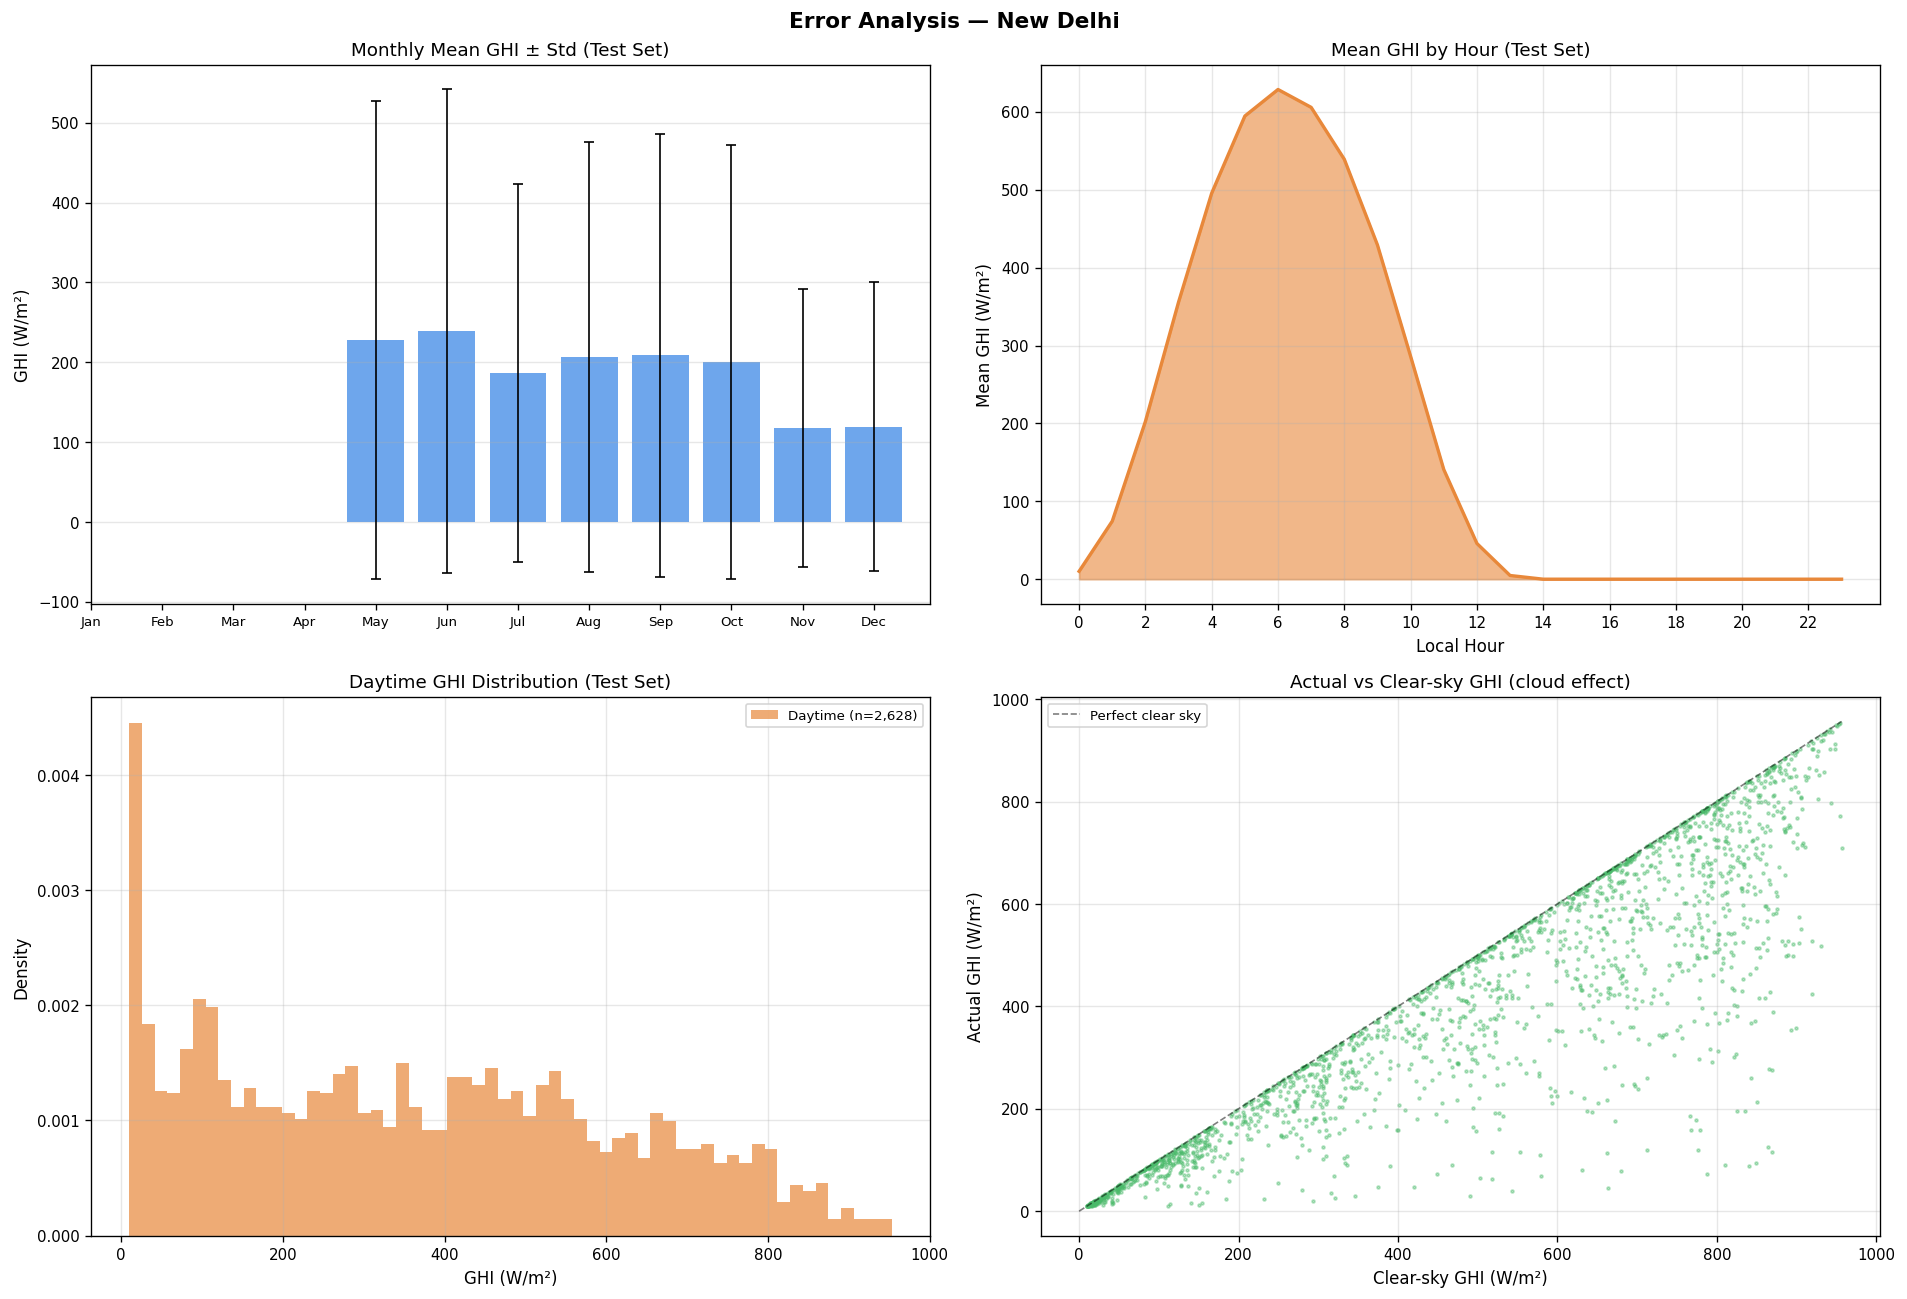

💾 Saved → ..\outputs/plots\09_error_analysis.png


In [8]:
# Load predictions saved during model training
# Use New Delhi as representative city
city    = "new_delhi"
df      = pd.read_csv(
    os.path.join(FEATURES_DIR, f"{city}_features.csv"),
    index_col="datetime", parse_dates=True
)
if df.index.tz is None:
    df.index = df.index.tz_localize("UTC")

n       = len(df)
te_idx  = int(n * (config.TRAIN_FRAC + config.VAL_FRAC))
test_df = df.iloc[te_idx:].copy()
test_df["local_hour"] = test_df.index.hour
test_df["month"]      = test_df.index.month

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f"Error Analysis — {city.replace('_',' ').title()}",
    fontsize=13, fontweight="bold"
)

# ── 1: GHI by month ───────────────────────────────────────────────
ax = axes[0, 0]
monthly_ghi = test_df.groupby("month")["GHI"].agg(
    ["mean","std"]
)
ax.bar(
    monthly_ghi.index,
    monthly_ghi["mean"],
    yerr=monthly_ghi["std"],
    capsize=3, color="#4A90E8", alpha=0.8,
    error_kw={"elinewidth": 1}
)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_NAMES, fontsize=8)
ax.set_ylabel("GHI (W/m²)")
ax.set_title("Monthly Mean GHI ± Std (Test Set)")
ax.grid(True, alpha=0.3, axis="y")

# ── 2: GHI by local hour ─────────────────────────────────────────
ax = axes[0, 1]
hourly_ghi = test_df.groupby("local_hour")["GHI"].mean()
ax.fill_between(
    hourly_ghi.index, 0, hourly_ghi.values,
    color="#E8883A", alpha=0.6
)
ax.plot(hourly_ghi.index, hourly_ghi.values,
        color="#E8883A", lw=2)
ax.set_xlabel("Local Hour")
ax.set_ylabel("Mean GHI (W/m²)")
ax.set_title("Mean GHI by Hour (Test Set)")
ax.set_xticks(range(0, 24, 2))
ax.grid(True, alpha=0.3)

# ── 3: Daytime vs nighttime GHI distribution ─────────────────────
ax = axes[1, 0]
daytime = test_df[test_df["GHI"] > DAYTIME_THR]["GHI"]
night   = test_df[test_df["GHI"] <= DAYTIME_THR]["GHI"]
ax.hist(daytime, bins=60, color="#E8883A",
        alpha=0.7, label=f"Daytime (n={len(daytime):,})",
        density=True)
ax.set_xlabel("GHI (W/m²)")
ax.set_ylabel("Density")
ax.set_title("Daytime GHI Distribution (Test Set)")
ax.legend()
ax.grid(True, alpha=0.3)

# ── 4: Clear sky vs actual ────────────────────────────────────────
ax = axes[1, 1]
daytime_df = test_df[test_df["GHI"] > DAYTIME_THR]
ax.scatter(
    daytime_df["clear_sky_ghi"].values[:2000],
    daytime_df["GHI"].values[:2000],
    s=3, alpha=0.4, color="#4ABA6A"
)
lim = max(
    daytime_df["clear_sky_ghi"].max(),
    daytime_df["GHI"].max()
)
ax.plot([0, lim], [0, lim], "k--", lw=1,
        alpha=0.5, label="Perfect clear sky")
ax.set_xlabel("Clear-sky GHI (W/m²)")
ax.set_ylabel("Actual GHI (W/m²)")
ax.set_title("Actual vs Clear-sky GHI (cloud effect)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "09_error_analysis.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")

In [9]:
print("=" * 70)
print("  FINAL SUMMARY TABLE — PUBLICATION READY")
print("=" * 70)

summary_rows = []
models_order = [
    "Persistence", "Climatology",
    "LinearRegression", "Ridge",
    "RandomForest", "XGBoost",
    "BiLSTM_h1", "NeuroSpike_h1",
]

for model in models_order:
    rows = h1[h1["model"] == model]
    if len(rows) == 0:
        continue
    summary_rows.append({
        "Model"      : model.replace("_h1",""),
        "Mean RMSE"  : round(rows["RMSE"].mean(),  3),
        "Std RMSE"   : round(rows["RMSE"].std(),   3),
        "Mean MAE"   : round(rows["MAE"].mean(),   3),
        "Mean R²"    : round(rows["R2"].mean(),    4),
        "Mean Skill" : round(rows["Skill"].mean(), 2)
                       if "Skill" in rows.columns
                       else np.nan,
        "Best City"  : rows.loc[rows["RMSE"].idxmin(), "city"],
        "Worst City" : rows.loc[rows["RMSE"].idxmax(), "city"],
    })

summary_table = pd.DataFrame(summary_rows).set_index("Model")

print(f"\n{summary_table.to_string()}")

# Save
table_path = os.path.join(METRICS_DIR, "final_summary_table.csv")
summary_table.to_csv(table_path)
print(f"\n💾 Saved → {table_path}")

  FINAL SUMMARY TABLE — PUBLICATION READY

                  Mean RMSE  Std RMSE  Mean MAE  Mean R²  Mean Skill Best City Worst City
Model                                                                                    
Persistence          91.373    15.456    58.714   0.8944         NaN    london     riyadh
Climatology          69.746    20.782    34.139   0.9229         NaN     dubai      tokyo
LinearRegression     54.403    18.549    31.261   0.9525         NaN     dubai     sydney
Ridge                54.315    18.563    31.056   0.9526         NaN     dubai     sydney
RandomForest         45.960    14.196    20.291   0.9663         NaN    riyadh     sydney
XGBoost              47.281    15.265    21.091   0.9642         NaN    riyadh     sydney
BiLSTM               45.520     8.431    25.411   0.9710       48.70     dubai     sydney
NeuroSpike           29.667     3.764    17.686   0.9877       66.43    riyadh  new_delhi

💾 Saved → ..\outputs/metrics\final_summary_table.csv


In [10]:
print("=" * 65)
print("  KEY FINDINGS")
print("=" * 65)

best_model  = summary_table["Mean RMSE"].idxmin()
worst_model = summary_table["Mean RMSE"].idxmax()
best_rmse   = summary_table.loc[best_model,  "Mean RMSE"]
pers_rmse   = summary_table.loc["Persistence","Mean RMSE"]
lstm_rmse   = summary_table.loc["BiLSTM",     "Mean RMSE"] \
              if "BiLSTM" in summary_table.index else np.nan
snn_rmse    = summary_table.loc["NeuroSpike", "Mean RMSE"] \
              if "NeuroSpike" in summary_table.index else np.nan

print(f"\n  1. Best overall model   : {best_model}")
print(f"     Mean RMSE            : {best_rmse:.3f} W/m²")

print(f"\n  2. Improvement over persistence:")
for model in ["XGBoost","BiLSTM","NeuroSpike"]:
    if model in summary_table.index:
        rmse   = summary_table.loc[model, "Mean RMSE"]
        improv = (1 - rmse / pers_rmse) * 100
        print(f"     {model:<14} : {improv:+.1f}%")

print(f"\n  3. BiLSTM vs NeuroSpike:")
if not np.isnan(lstm_rmse) and not np.isnan(snn_rmse):
    diff = lstm_rmse - snn_rmse
    winner = "NeuroSpike" if diff > 0 else "BiLSTM"
    print(f"     BiLSTM     RMSE : {lstm_rmse:.3f} W/m²")
    print(f"     NeuroSpike RMSE : {snn_rmse:.3f} W/m²")
    print(f"     Winner          : {winner} "
          f"(by {abs(diff):.3f} W/m²)")

print(f"\n  4. Easiest city to forecast:")
city_mean = h1[h1["model"].str.contains(
    "NeuroSpike|BiLSTM", na=False
)].groupby("city")["RMSE"].mean()
print(f"     {city_mean.idxmin()} "
      f"(RMSE={city_mean.min():.3f} W/m²)")

print(f"\n  5. Hardest city to forecast:")
print(f"     {city_mean.idxmax()} "
      f"(RMSE={city_mean.max():.3f} W/m²)")

print(f"\n  Ready for → 10_forecasting.ipynb")

  KEY FINDINGS

  1. Best overall model   : NeuroSpike
     Mean RMSE            : 29.667 W/m²

  2. Improvement over persistence:
     XGBoost        : +48.3%
     BiLSTM         : +50.2%
     NeuroSpike     : +67.5%

  3. BiLSTM vs NeuroSpike:
     BiLSTM     RMSE : 45.520 W/m²
     NeuroSpike RMSE : 29.667 W/m²
     Winner          : NeuroSpike (by 15.853 W/m²)

  4. Easiest city to forecast:
     dubai (RMSE=30.849 W/m²)

  5. Hardest city to forecast:
     sydney (RMSE=47.267 W/m²)

  Ready for → 10_forecasting.ipynb
